In [1]:
%load_ext autoreload
%autoreload 2

In [62]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

In [63]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [64]:
style_size = 'paper'

## New Plots

In [65]:
training_times = {
    'cyclic_4':10_000,
    'cyclic_16':10_000,
    'tree_7': 25_000, 
    'tree_31': 25_000,
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}

name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose': 'Glucose',
    'pong': "Pong",
    'boxing': "Boxing"
}

methods_to_nice = {
    'random': 'Random',
    'entropy': 'Entropy',
    'greedy': 'Greedy',
    'lp': "LP",
    'multiple': "Multiple"
}

methods_dict = {
    0: 'Random',
    1: 'Entropy',
    2: 'Greedy',
    3: 'LP',
    4: 'Policy LP',
    5: 'Multiple'
    
}

method_scales = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d+21)/42*100, lambda d: d/100*100, lambda d: (d+20)/(55+20)*100]

In [66]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","random","entropy","greedy","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_perfect = []
all_performances_imperfect = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        if m == 'multiple':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison'})
    matching_params = [i for i in matching_params if 'ground_truth' in i]
    performance = method_scales[j](np.mean([i['ground_truth']['reward'] for i in matching_params]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(498.1666666666667, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 3 [(170.72916666666666, 42, [0, 9, 10]), (306.8050314465409, 43, [6, 7, 11]), (448.6542056074766, 44, [5, 6, 9])]
Perfect cart_pole entropy 3 [(122.9801488833747, 43, [9, 0, 3]), (292.45454545454544, 42, [10, 9, 3]), (117.80952380952381, 44, [0, 9, 3])]
Perfect cart_pole greedy 3 [(124.39393939393939, 43, [4, 3, 10]), (100.18052738336714, 42, [10, 4, 3]), (40.320647773279354, 44, [3, 4, 1])]
Perfect cart_pole lp_hybrid 3 [(400.975, 44, [5, 6, 7]), (348.15107913669067, 42, [4, 6, 7]), (414.70940170940173, 43, [6, 7, 10])]
Perfect mini_grid perfect_concepts 3 [(0.9589964280213279, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]), (0.9598

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


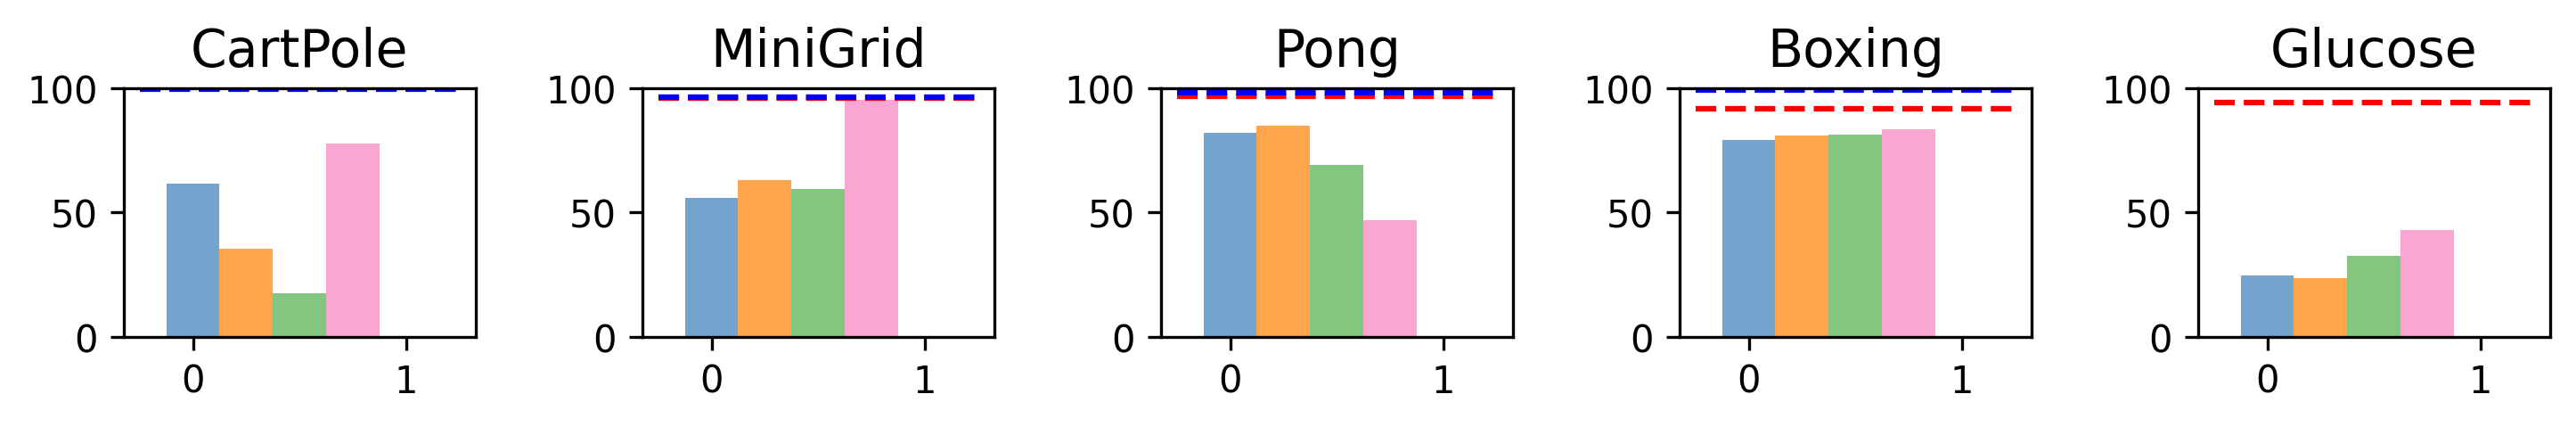

In [67]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect[i][:-1])))
    y_vals = all_performances_perfect[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_perfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


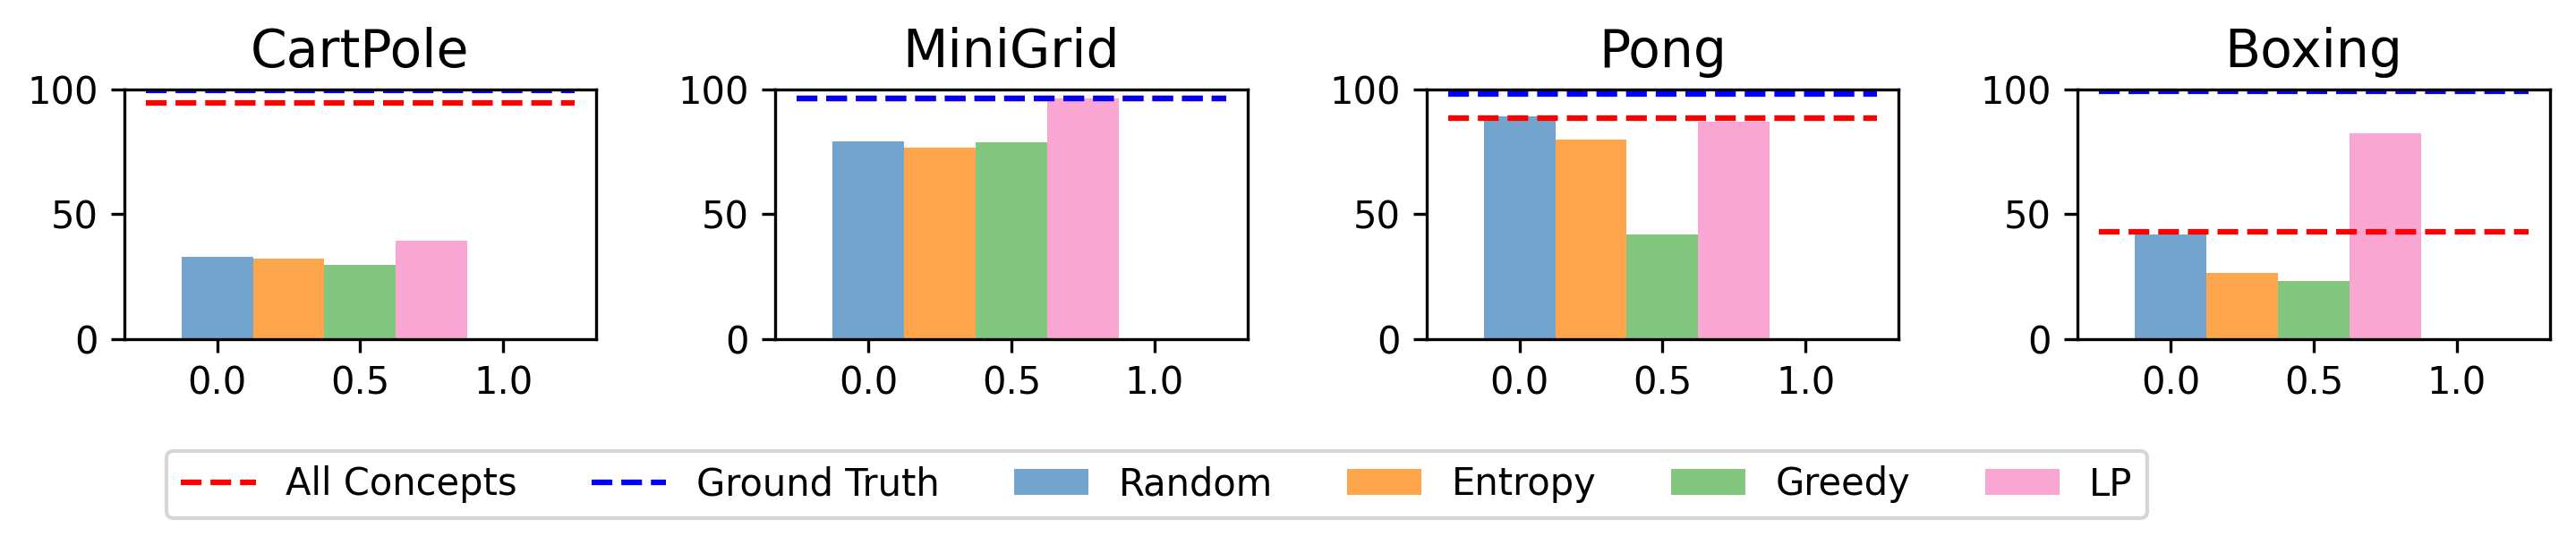

In [12]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect[i][:-1])))
    y_vals = all_performances_imperfect[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [13]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[2,5,10]]
accuracies = [0.75,0.85,0.95]
max_perf = [i+0.001 for i in all_baselines]
max_perf[3] = 100
max_perf[2] = 21
heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(perfect_environments))]

for i,e in enumerate(perfect_environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params),[m['multiple']['reward'] for m in matching_params],round(np.mean([m['multiple']['reward'] for m in matching_params])/max_perf[i],2)*100)
            if len(matching_params) > 0 and 'multiple' in matching_params[0]:
                heatmap_by_env[i][j][k] = round(method_scales[i](np.mean([m['multiple']['reward'] for m in matching_params])))

cart_pole 0.75 1 3 [41.38704318936877, 38.26825518831668, 45.68135904499541] 42.0
cart_pole 0.75 2 3 [41.06286186931348, 47.113421550094515, 51.714880332986475] 47.0
cart_pole 0.75 3 3 [51.22966014418126, 95.72093023255815, 47.97019230769231] 65.0
cart_pole 0.85 1 3 [43.05613126079447, 43.91879964695499, 54.2308533916849] 47.0
cart_pole 0.85 2 3 [75.94036697247707, 45.40582347588717, 50.81122448979592] 57.99999999999999
cart_pole 0.85 3 3 [55.67673378076063, 200.70781893004116, 73.02058823529411] 110.00000000000001
cart_pole 0.95 1 3 [43.687445127304656, 43.90669014084507, 61.17589175891759] 50.0
cart_pole 0.95 2 3 [60.55596107055961, 124.36934673366834, 47.04824976348155] 78.0
cart_pole 0.95 3 3 [58.996437054631826, 142.70058139534885, 361.23703703703706] 188.0
mini_grid 0.75 3 3 [0.34474487615874294, 0.27174559475361615, 0.3069807401133908] 0.0
mini_grid 0.75 6 3 [0.338770422638512, 0.31388695721609006, 0.3521259522458674] 0.0
mini_grid 0.75 11 3 [0.33045428664024384, 0.3890993478981

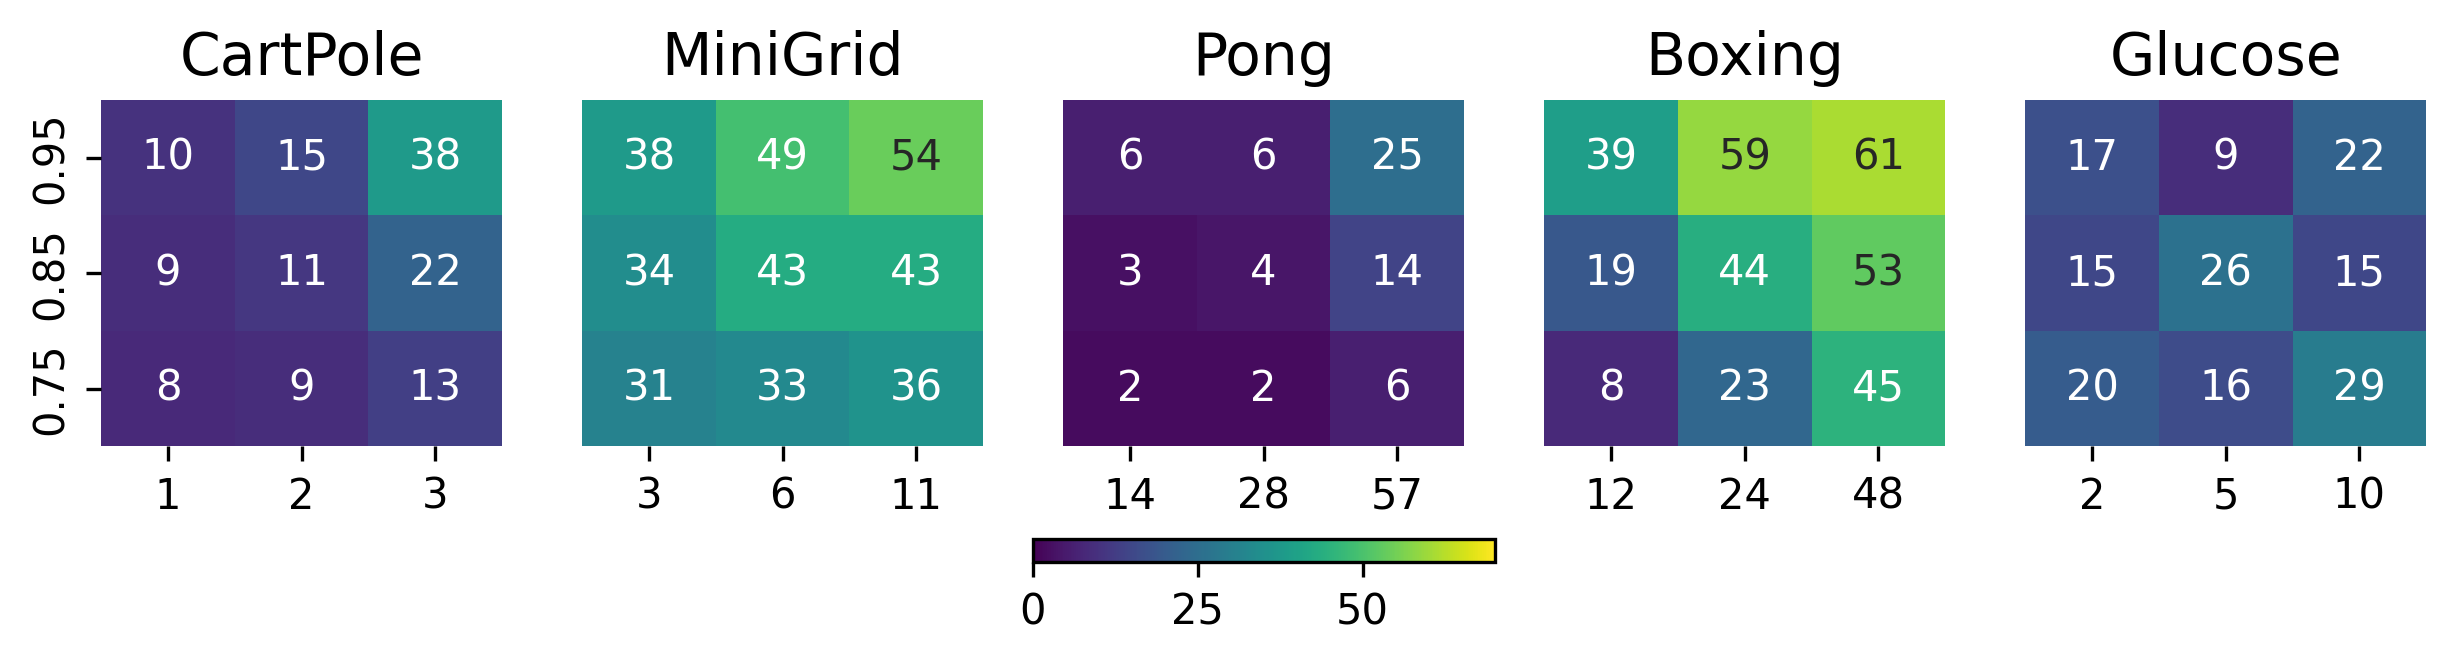

In [14]:
plot_dimensions = (1,len(perfect_environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(perfect_environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = [[name_to_nice[i] for i in perfect_environments]]
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(perfect_environments)):
    annot = accuracies 
    if i!=0:
        annot = [] 
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=annot,
        vmin=0, vmax=70,   # ensure consistent scaling
        cbar=False,
        annot=True
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=70)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.20          # spacing from subplots
)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [15]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.95]
environment = "mini_grid"
rewards = []

for acc in concept_accuracies:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        print(acc,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_accuracy = np.array(rewards)

0.75 250000 3
0.75 500000 3
0.75 750000 3
0.75 1000000 3
0.85 250000 3
0.85 500000 3
0.85 750000 3
0.85 1000000 3
0.95 250000 3
0.95 500000 3
0.95 750000 3
0.95 1000000 3


In [16]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []

for n in num_concepts_selected:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_num_concepts = np.array(rewards)
rewards_num_concepts

3 250000 3
3 500000 3
3 750000 3
3 1000000 3
6 250000 3
6 500000 3
6 750000 3
6 1000000 3
11 250000 3
11 500000 3
11 750000 3
11 1000000 3


array([[22.71557953, 38.1955301 , 39.514523  , 38.40815411],
       [32.1309221 , 48.63486737, 41.63637068, 42.73954345],
       [40.7307803 , 53.8473115 , 58.79269046, 64.10559454]])

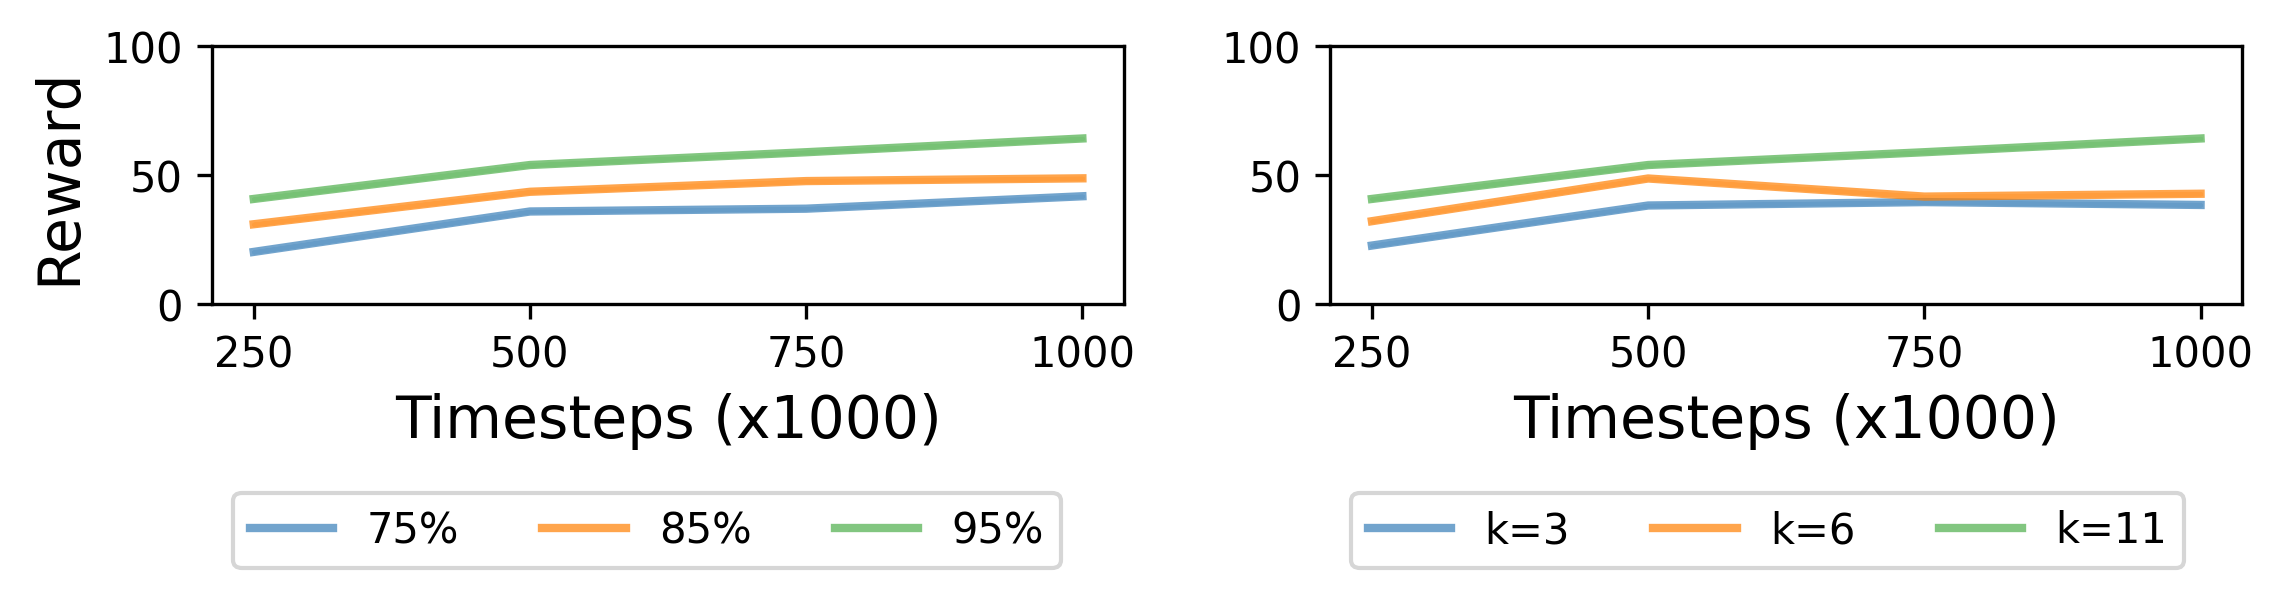

In [17]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,2)
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(2)] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res


sup_y_label = ""
overall_format = {'figsize':(8,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[[0,1,2,3],["250","500","750","1000"]] for i in range(2)]],
    'y_ticks': [[[[0,50,100],["0","50","100"]] for i in range(2)]],
    'y_lim': [[[0,100] for i in range(2)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=[["Reward",""]],x_labels=[["Timesteps (x1000)","Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_accuracy
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][0],x_groups,y_vals,y_std,["{}%".format(round(i*100)) for i in concept_accuracies],line_format)

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_num_concepts 
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][1],x_groups,y_vals,y_std,["k={}".format(i) for i in num_concepts_selected],line_format)


legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0,-1.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/accuracy_num_concepts.pdf",dpi=300, bbox_inches='tight')

In [21]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_intervention = []

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': 0.5})

        print(e,m,len(matching_params))
        if len(matching_params) > 0:
            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    all_performances_intervention.append(temp)

all_performances_imperfect = []

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m})


        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i]))
        temp.append(performance)
    all_performances_imperfect.append(temp)

cart_pole imperfect_concepts 3
cart_pole random 3
cart_pole entropy 3
cart_pole greedy 3
cart_pole lp_hybrid 0
mini_grid imperfect_concepts 3
mini_grid random 3
mini_grid entropy 3
mini_grid greedy 3
mini_grid lp_hybrid 0
pong imperfect_concepts 3
pong random 3
pong entropy 3
pong greedy 3
pong lp_hybrid 0
boxing imperfect_concepts 3
boxing random 3
boxing entropy 3
boxing greedy 3
boxing lp_hybrid 0


4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


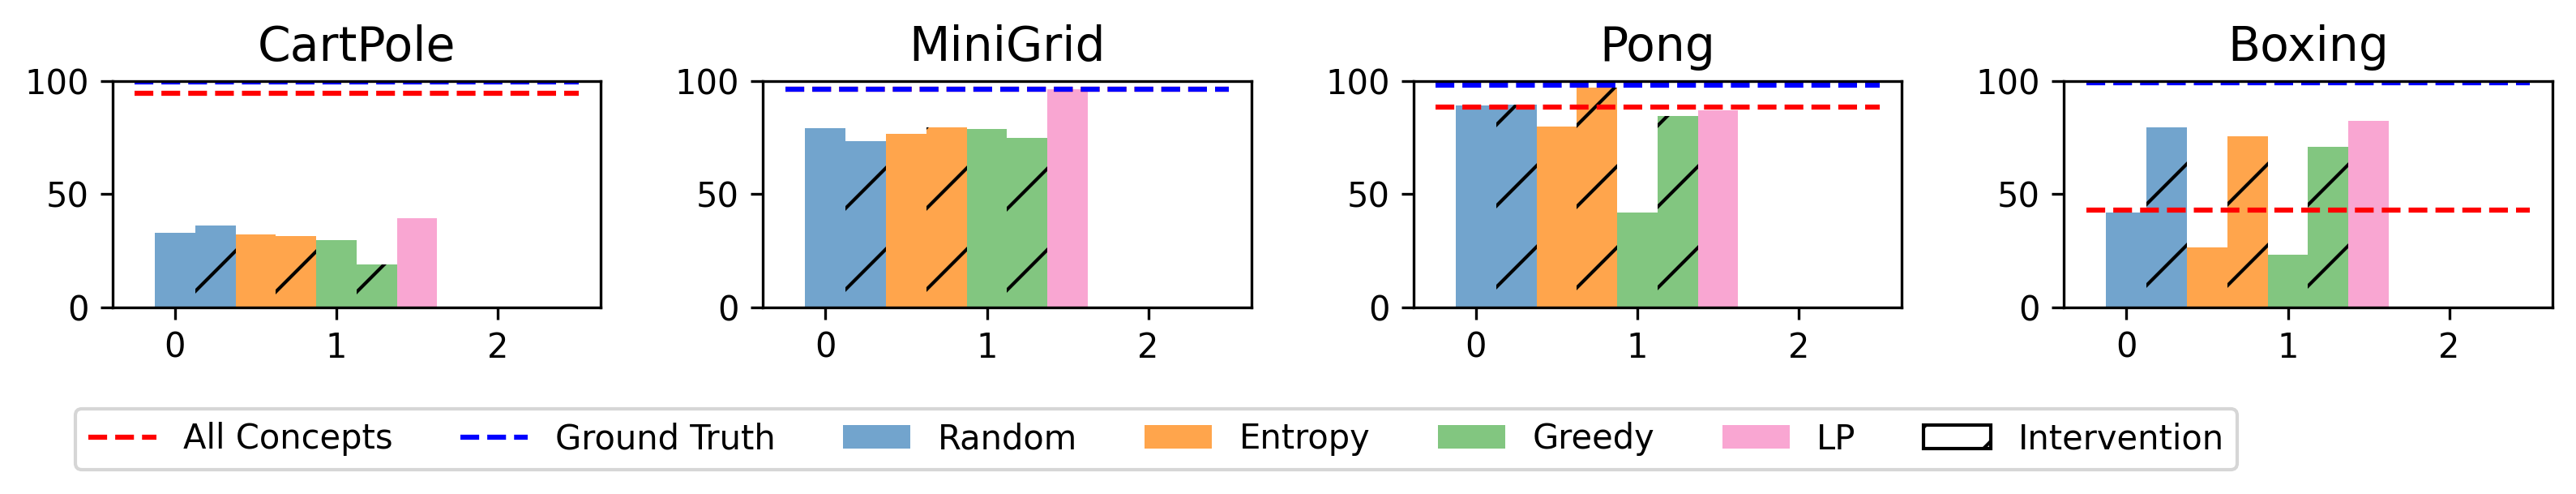

In [22]:
import matplotlib.patches as mpatches

plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(11,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

plt.tight_layout()

for i in range(len(imperfect_environments)):

    x_groups = 2*np.array(list(range(len(all_performances_intervention[i][1:]))))
    y_vals = all_performances_imperfect[i][1:]

    d = {
        0: 'Random',
        2: 'Entropy',
        4: 'Greedy',
        6: 'LP',
        8: 'Imperfect'
    }

    bar_format = {'color_palette': 'six_color', 'style_size': style_size}

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)
    
    x_groups = 2*np.array(list(range(len(all_performances_intervention[i][1:]))))+1
    y_vals = all_performances_intervention[i][1:]
    d = {
        1: '',
        3: '',
        5: '',
        7: '',
        9: ''
    }

    bar_format = {'color_palette': 'six_color', 'style_size': style_size, 'hatch': '/'}
    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,2.5,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,2.5,label="Ground Truth",color="blue",linestyle="--")

striped_patch = mpatches.Patch(
    facecolor='white',    # or a specific color from your palette
    edgecolor='black',
    hatch='/',
    label='Intervention'
)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 8, 'bbox_to_anchor': (0.04,-0.1),'fontsize': 14,
                     'extra_handles': [(striped_patch, 'Intervention')]}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_intervention.pdf",dpi=300, bbox_inches='tight')

In [60]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0])
for i in intervention_probability:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions.append(temp)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append(all_performances_perfect[0])

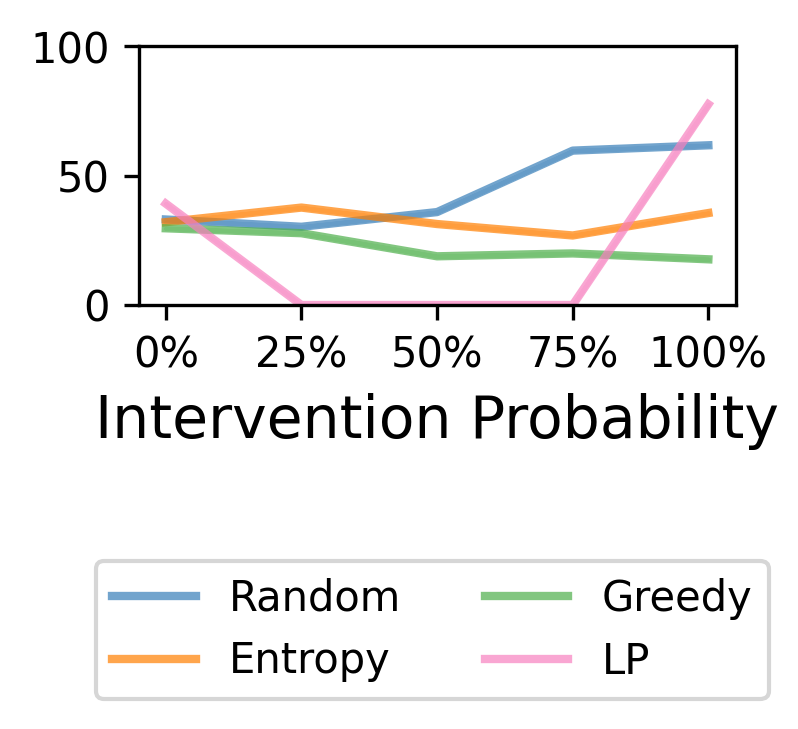

In [61]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [[""]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),["0%","25%","50%","75%","100%"]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Intervention Probability"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(intervention_probability))) for j in imperfect_methods[1:]]
y_vals = np.array(cart_pole_interventions).T[1:]
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,['Random','Entropy','Greedy','LP'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.15,-0.3),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')


In [56]:
e = 'cart_pole'
matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': 'multiple', 'intervention_prob': 0.5})
accuracies = np.array(matching_params[0]['concept_accuracy'])
intervention_probability = [0.25,0.5,0.75]

selected_concepts = []
for m in imperfect_methods[1:]:
    matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                'num_concepts_selected': num_concepts_selected[e],
                                                                'method': m, 'intervention_prob': 0.5})
    selected_concepts.append(matching_params[0][m]['concepts'])

baseline_accuracies = [accuracies[i] for i in selected_concepts]
intervention_accuracies = []
for i in intervention_probability:
    intervention_accuracies.append([(i)*np.ones(3) + (1-i)*j for j in baseline_accuracies])
intervention_accuracies = np.array(intervention_accuracies)
intervention_accuracies = np.mean(intervention_accuracies,axis=2)
baseline_accuracies = [np.mean(i) for i in baseline_accuracies]

cart_pole_intervention_performance = cart_pole_interventions[1][1:]
cart_pole_baseline_performance = all_performances_imperfect[0][1:]
baseline_combo = np.array(list(zip(baseline_accuracies,cart_pole_baseline_performance)))
intervention_combo = np.array(list(zip(intervention_accuracies[1],cart_pole_intervention_performance)))

IndexError: list index out of range

NameError: name 'intervention_combo' is not defined

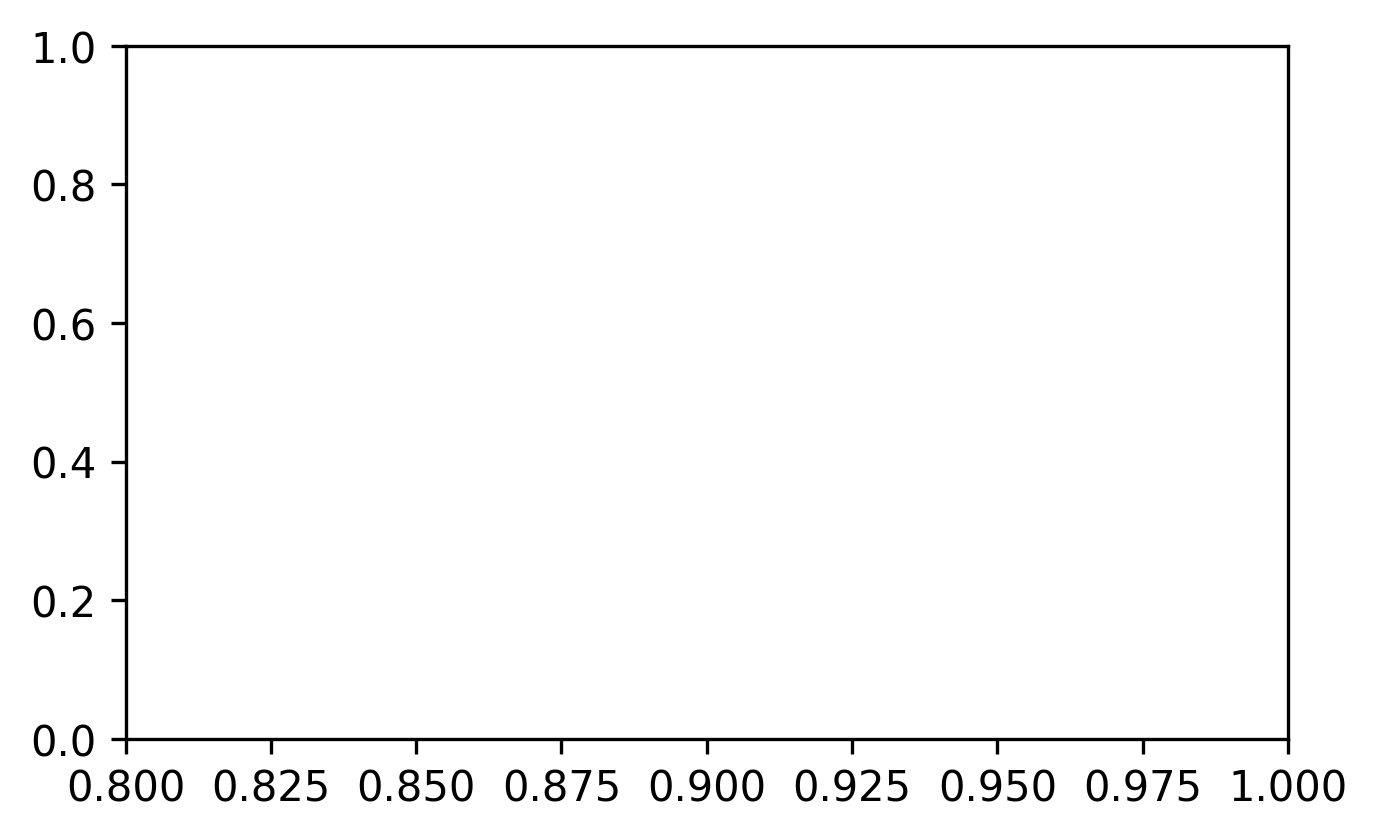

In [30]:
import matplotlib.lines as mlines

plt.figure(figsize=(5,3))

plt.xlim([0.8,1])
# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']  # extend if needed

for i, (x, y) in enumerate(intervention_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Intervention' if i == 0 else None,
        color='C0'
    )

# Plot baseline with unique markers
for i, (x, y) in enumerate(baseline_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Baseline' if i == 0 else None,
        color='C1'
    )

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention_combo)
baseline_pf     = pareto_front(baseline_combo)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        y_min, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y_min,y0], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines
extend_to_axes(intervention_pf, color='tab:blue')
extend_to_axes(baseline_pf,      color='tab:orange')

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Accuracy")
plt.ylabel("Reward")
plt.ylim([75,375])

unique_n = len(intervention_combo)               # e.g., 4
unique_markers = markers[:unique_n]             # use the first N markers
marker_labels = imperfect_methods[1:]

marker_handles = [
    mlines.Line2D(
        [], [], 
        color='black',                 # neutral color for legend
        marker=unique_markers[i],
        linestyle='None',
        markersize=8,
        label=marker_labels[i]
    )
    for i in range(unique_n)
]

# After your existing plt.legend():

# Add the marker-only legend
intervention_handle = mlines.Line2D(
    [], [], color='C0', marker='o', linestyle='None',
    markersize=8, label='Intervention'
)

baseline_handle = mlines.Line2D(
    [], [], color='C1', marker='o', linestyle='None',
    markersize=8, label='Baseline'
)

# ----------------------------------------------------
# Marker entries (same color, different markers)
# ----------------------------------------------------
unique_n = len(intervention_combo)
unique_markers = markers[:unique_n]

marker_handles = [
    mlines.Line2D(
        [], [], 
        color='C0',               # same color for all marker examples
        marker=unique_markers[i],
        linestyle='None',
        markersize=8,
        label=imperfect_methods[i+1]
    )
    for i in range(unique_n)
]

# ----------------------------------------------------
# Combine everything into one legend
# ----------------------------------------------------
all_handles = [intervention_handle, baseline_handle] + marker_handles

plt.legend(handles=all_handles, title="Legend", loc="best")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("../../results/figures/pareto_reward.pdf",dpi=300, bbox_inches='tight')



In [119]:
gold_timesteps = [100000,250000,500000]
methods = ["greedy","lp","multiple"]
e = "mini_grid"

performance_by_gold = []
for m in methods:
    temp = []
    for g in gold_timesteps:
        matching_params = get_results_matching_parameters("ablations","",{'environment_string': e,'gold_timesteps':g,
                                                                    'method': m})
        if len(matching_params) > 0:
            val = method_scales[1](np.mean([i[m]['reward'] for i in matching_params]))
        else:
            val = 0
        temp.append(val)
    performance_by_gold.append(temp)
np.array(performance_by_gold)

array([[48.12597178, 39.75212372, 54.16675992],
       [92.65338998, 93.46465301, 87.47164523],
       [56.39063332, 88.33987706, 65.15886066]])

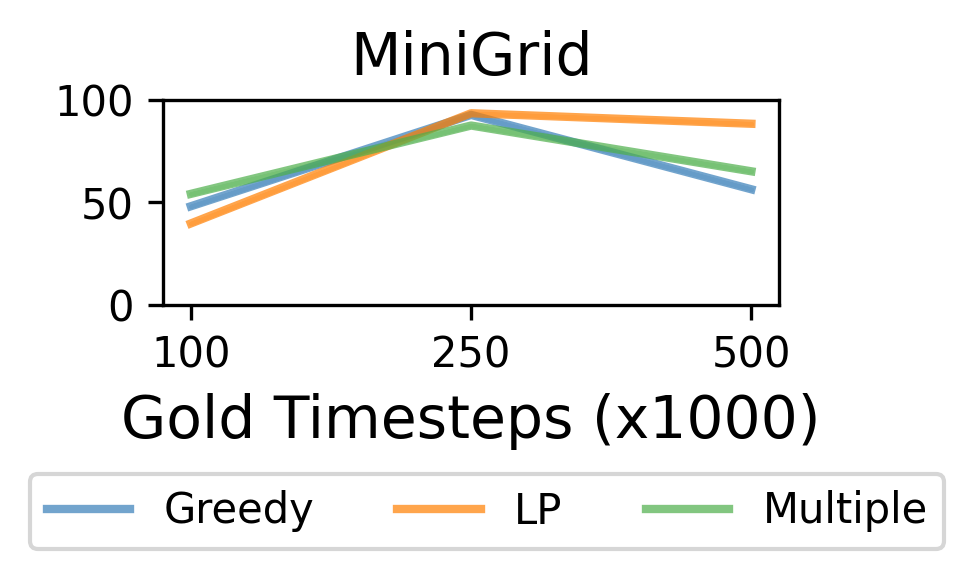

In [121]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [["MiniGrid"]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(gold_timesteps))),[str(g//1000) for g in gold_timesteps]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Gold Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(gold_timesteps))) for j in methods]
y_vals = np.array(performance_by_gold).T
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,["Greedy","LP","Multiple"],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.05,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/gold_timesteps.pdf",dpi=300, bbox_inches='tight')

In [9]:
all_performances_imperfect_ablation = deepcopy(all_performances_imperfect)
for j,e in enumerate(["cart_pole","mini_grid"]):
    temp = []    
    for m in ["completeness","lp_policy"]:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,
                                                                        'method': m})
        all_performances_imperfect_ablation[j].append(method_scales[j](np.mean([i[m]['reward'] for i in matching_params])))

7 eight_color 1
7 eight_color 1


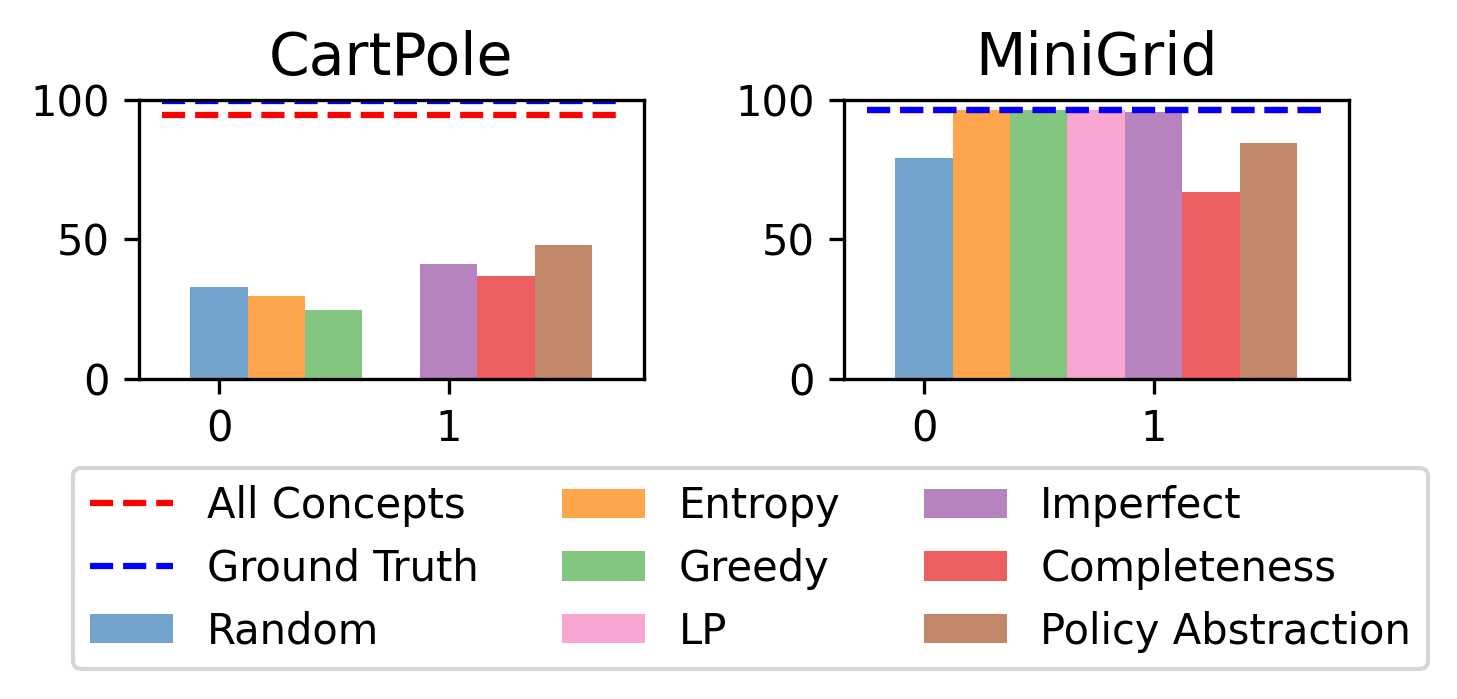

In [10]:
imperfect_environments = ["CartPole","MiniGrid"]
plot_dimensions = (1,len(imperfect_environments))

titles = [imperfect_environments]

sup_y_label = ""
overall_format = {'figsize':(5,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,21],[0,100]]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'eight_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_ablation[i][:-1])))
    y_vals = all_performances_imperfect_ablation[i][1:]
    
    d = {
        0: 'Random',
        1: 'Entropy',
        2: 'Greedy',
        3: 'LP',
        4: 'Imperfect',
        5: 'Completeness',
        6: 'Policy Abstraction'
    }

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.75,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.75,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.075,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect_ablation.pdf",dpi=300, bbox_inches='tight')

In [28]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311})
matching_params = [i for i in matching_params if 'epochs' not in i['parameters']]
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

In [29]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


In [129]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity = np.mean(similarity,axis=1)

In [130]:
imperfect_lp_intervention = [[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
imperfect_lp_intervention = np.mean(imperfect_lp_intervention,axis=0)
multiple_lp_intervention = [[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
multiple_lp_intervention = np.mean(multiple_lp_intervention,axis=0)

greedy_intervention = [[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
greedy_intervention = np.mean(greedy_intervention,axis=0)

random_selection_intervention = [[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
random_selection_intervention = np.mean(random_selection_intervention,axis=0)


chosen_concepts_intervention = [[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
chosen_concepts_intervention = np.mean(chosen_concepts_intervention,axis=0)


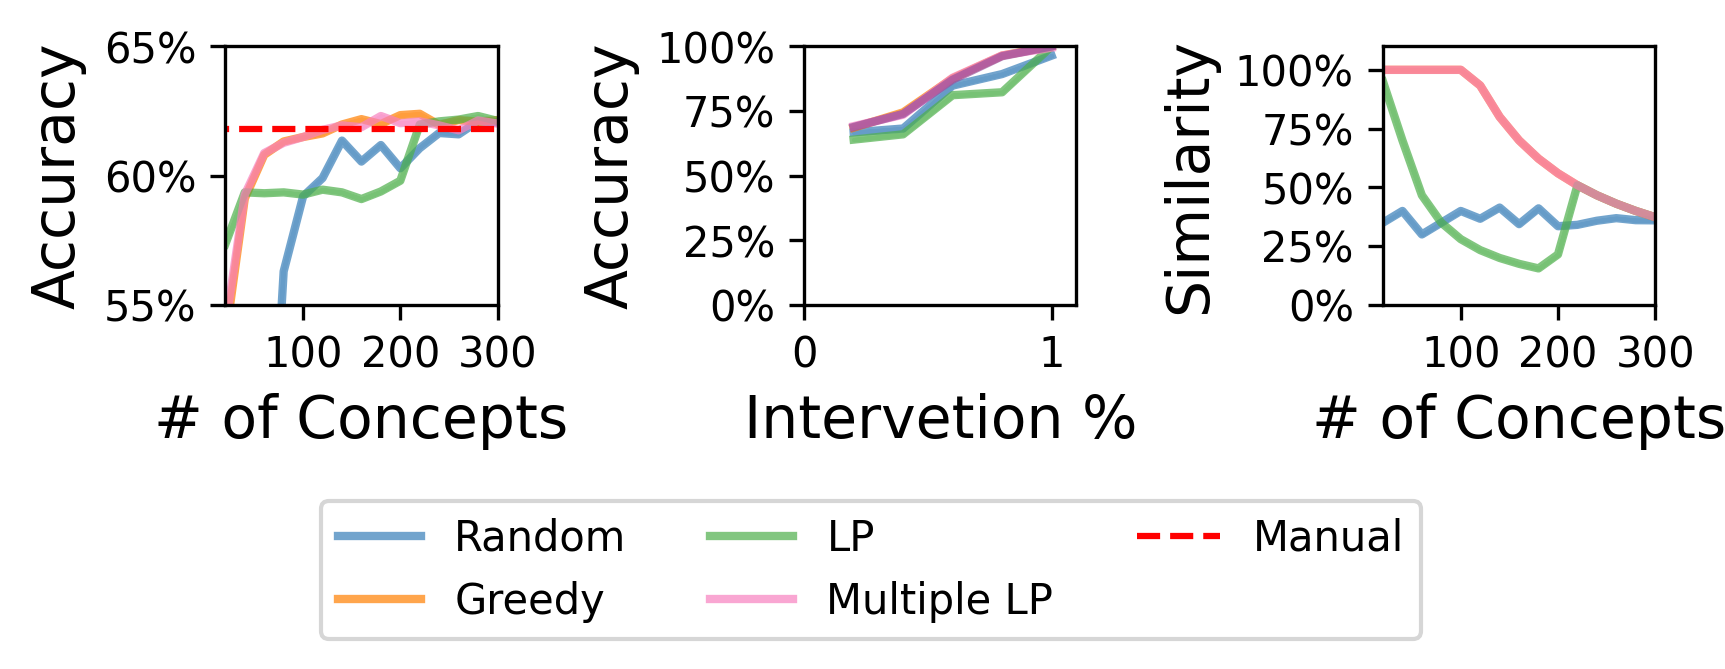

In [54]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)

sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300],[0,1.1],[20,300]]],
    'y_lim': [[[0.55,0.65],[0,1],[0,1.1]]],
    'y_ticks': [[[[0.55,0.6,0.65],["55%","60%","65%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts","Intervetion %","# of Concepts"]],y_labels=[["Accuracy","Accuracy","Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection,greedy,imperfect_lp,multiple_lp]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")
line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","LP","Multiple LP","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection_intervention,greedy_intervention,imperfect_lp_intervention,multiple_lp_intervention,chosen_concepts_intervention]]

plot_line(ax[0][1],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)


all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity_random,similarity_greedy,similarity,similarity_multiple]]

plot_line(ax[0][2],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.2,-0.2),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')